PROBLEM STATEMENT

E-commerce platforms generate large volumes of customer interaction data across different stages of the buying journey.
Most existing analytics systems only describe past behavior and identify drop-offs after they occur.
They do not predict drop-off stages in advance or account for differences in customer intent. businesses struggle to identify high risk churn users early.
This project analyzes customer journeys to understand behavioral patterns across the funnel.
Machine learning models are used to predict drop-off stages and churn risk.
The goal is to support proactive, personalized marketing actions that reduce churn.

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


In [ ]:
data=pd.read_csv('/content/ecommerce_price_behavioral.csv')
data.head()

,UserID,SessionID,Timestamp,EventType,ProductID,Amount,Outcome,product_name,product_price,price_behavioral
0,1,1,2024-07-07 18:00:26.959902,page_view,NaN,NaN,Not_Purchased,Cotton T-Shirt,733,1502.0
1,1,1,2024-03-05 22:01:00.072000,page_view,NaN,NaN,Not_Purchased,Power Bank,1080,2392.0
2,1,1,2024-03-23 22:08:10.568453,product_view,prod_8199,NaN,Not_Purchased,Digital Alarm Clock,2905,6109.0
3,1,1,2024-03-12 00:32:05.495638,add_to_cart,prod_4112,NaN,Not_Purchased,Digital Alarm Clock,2020,4131.0
4,1,1,2024-02-25 22:43:01.318876,add_to_cart,prod_3354,NaN,Not_Purchased,Yoga Mat,1690,3251.0


**BASIC CHECKS**

In [ ]:
data.shape

(74817, 10)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74817 entries, 0 to 74816
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   UserID            74817 non-null  int64  
 1   SessionID         74817 non-null  int64  
 2   Timestamp         74817 non-null  object 
 3   EventType         74817 non-null  object 
 4   ProductID         32113 non-null  object 
 5   Amount            10682 non-null  float64
 6   Outcome           74817 non-null  object 
 7   product_name      74817 non-null  object 
 8   product_price     74817 non-null  int64  
 9   price_behavioral  74817 non-null  float64
dtypes: float64(2), int64(3), object(5)
memory usage: 5.7+ MB


In [ ]:
data['product_name'].value_counts()

,count
product_name,
Sunglasses,3829
Laptop Backpack,3811
Headphones,3810
Gaming Mouse,3809
Travel Bag,3794
Wireless Earbuds,3777
LED Table Lamp,3777
Office Chair,3774
USB Cable,3754


In [ ]:
data.isnull().sum()

,0
UserID,0
SessionID,0
Timestamp,0
EventType,0
ProductID,42704
Amount,64135
Outcome,0
product_name,0
product_price,0
price_behavioral,0


In [ ]:
data['EventType'].value_counts()

,count
EventType,
page_view,10819
add_to_cart,10735
product_view,10696
logout,10685
purchase,10682
click,10632
login,10568


**Preprocessing**

In [ ]:
data['Timestamp'] = pd.to_datetime(data['Timestamp'])

In [ ]:
data[data.duplicated()]

,UserID,SessionID,Timestamp,EventType,ProductID,Amount,Outcome,product_name,product_price,price_behavioral


In [ ]:
data = data.drop(columns=['Amount','ProductID','product_price'])

In [ ]:
data.rename(columns={'price_behavioral': 'product_price'}, inplace=True)

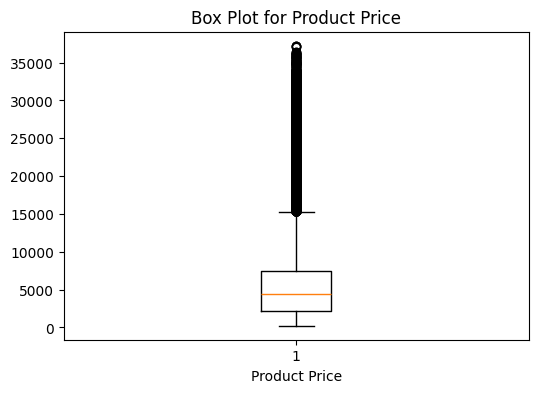

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(data['product_price'])
plt.xlabel('Product Price')
plt.title('Box Plot for Product Price')
plt.show()

In [ ]:
Q1 = data['product_price'].quantile(0.25)
Q3 = data['product_price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = data[(data['product_price'] < lower) |(data['product_price'] > upper)]
outlier_percentage = (len(outliers) / len(data)) * 100
outlier_percentage


5.883689535800687

**CUSTOMER JOURNEY**

feature engineering

In [ ]:
data = data.sort_values(['UserID', 'Timestamp'])

data['time_diff_hours'] = (data.groupby('UserID')['Timestamp'].diff().dt.total_seconds() / 3600)

data['new_journey'] = ((data['time_diff_hours'] > 24) | (data['time_diff_hours'].isna()))

data['journey_id'] = data.groupby('UserID')['new_journey'].cumsum()

journey_features = data.groupby(['UserID','journey_id']).agg(
    page_views=('EventType', lambda x: (x == 'page_view').sum()),
    product_views=('EventType', lambda x: (x == 'product_view').sum()),
    cart_adds=('EventType', lambda x: (x == 'add_to_cart').sum()),
    has_purchase=('EventType', lambda x: int((x == 'purchase').any()))).reset_index()

journey_features['total_events'] = (journey_features['page_views'] +journey_features['product_views'] +journey_features['cart_adds'])


In [ ]:
data.head(5)

,UserID,SessionID,Timestamp,EventType,Outcome,product_name,product_price,time_diff_hours,new_journey,journey_id
5,1,1,2024-01-01 23:09:51.956825,page_view,Not_Purchased,Yoga Mat,1421.0,NaN,True,1
32,1,4,2024-01-02 00:15:51.420238,add_to_cart,Not_Purchased,Yoga Mat,3640.0,1.099851,False,1
36,1,5,2024-01-03 23:51:05.729189,logout,Not_Purchased,Running Shoes,9247.0,47.587308,True,2
29,1,4,2024-01-04 09:25:49.705624,add_to_cart,Not_Purchased,Running Shoes,12087.0,9.578882,False,2
65,1,8,2024-01-04 17:09:29.677060,click,Not_Purchased,Phone Case,2089.0,7.727770,False,2


In [ ]:
def journey_drop_stage(row):
    if row['has_purchase']:
        return 'Purchase'
    elif row['cart_adds'] > 0:
        return 'Add_to_Cart'
    elif row['product_views'] > 0:
        return 'Product_View'
    elif row['page_views'] > 0:
        return 'Website_Visit'
    else:
        return 'No_Action'

journey_features['drop_stage'] = journey_features.apply(journey_drop_stage, axis=1)


In [ ]:
journey_features.head()

,UserID,journey_id,page_views,product_views,cart_adds,has_purchase,total_events,drop_stage
0,1,1,1,0,1,0,2,Add_to_Cart
1,1,2,0,0,1,0,1,Add_to_Cart
2,1,3,1,0,0,0,1,Website_Visit
3,1,4,0,1,0,0,1,Product_View
4,1,5,0,0,1,0,1,Add_to_Cart


In [ ]:
journey_features.drop_stage.value_counts()

,count
drop_stage,
No_Action,17976
Purchase,10047
Add_to_Cart,8977
Product_View,8143
Website_Visit,7362


In [ ]:
product = (data.groupby(['UserID', 'journey_id'])[['product_name','product_price']].first().reset_index())


In [ ]:
journey_features = journey_features.merge(product,on=['UserID', 'journey_id'],how='left')
journey_features.head(2)

,UserID,journey_id,page_views,product_views,cart_adds,has_purchase,total_events,drop_stage,product_name,product_price
0,1,1,1,0,1,0,2,Add_to_Cart,Yoga Mat,1421.0
1,1,2,0,0,1,0,1,Add_to_Cart,Running Shoes,9247.0


In [ ]:
drop_counts = journey_features['drop_stage'].value_counts().reset_index()
drop_counts.columns = ['drop_stage', 'count']

fig = px.bar(drop_counts,x='drop_stage',y='count',color='drop_stage',title='Distribution of Customer Drop-Off Stages')

fig.show()


Most users exit the platform without meaningful engagement, while a smaller portion completes a purchase. The most critical churn point occurs at the AddtoCart stage, where users show strong intent but fail to convert. Additional drop offs occur during product exploration and initial website visits

In [ ]:
avg_actions = (journey_features.groupby('drop_stage')[['page_views','product_views','cart_adds']].mean().reset_index())

fig = px.bar(avg_actions,x='drop_stage',y=['page_views','product_views','cart_adds'],barmode='stack',title='Average Actions by Drop-Off Stage')

fig.show()


In [ ]:
avg_actions_purchase = (journey_features.groupby('has_purchase')[['page_views','product_views','cart_adds']].mean().reset_index())

fig = px.bar(avg_actions_purchase,x='has_purchase',y=['page_views','product_views','cart_adds'],barmode='group',
    title='Average Actions: Purchase vs Non-Purchase')

fig.show()


**CHURN ANALYSIS**

In [ ]:
#high-risk churn journeys
journey_features['churn_risk'] = 'Low'

journey_features.loc[(journey_features['cart_adds'] > 0) & (journey_features['has_purchase'] == 0),'churn_risk'] = 'High'

journey_features.loc[(journey_features['product_views'] > 0) &(journey_features['cart_adds'] == 0) &(journey_features['has_purchase'] == 0),'churn_risk'] = 'Medium'


In [ ]:
journey_features.head(2)

,UserID,journey_id,page_views,product_views,cart_adds,has_purchase,total_events,drop_stage,product_name,product_price,churn_risk
0,1,1,1,0,1,0,2,Add_to_Cart,Yoga Mat,1421.0,High
1,1,2,0,0,1,0,1,Add_to_Cart,Running Shoes,9247.0,High


In [ ]:
churn_counts = (journey_features['churn_risk'].value_counts().reset_index())

churn_counts.columns = ['churn_risk', 'count']

churn_dist= px.bar(churn_counts,x='churn_risk',y='count',color='churn_risk',title='Distribution of Churn Risk Levels')

churn_dist.show()


In [ ]:
price = px.histogram(journey_features,x='product_price',color='churn_risk',nbins=30,barmode='group',title='Product Price Distribution by Churn Risk Level')

price.show()

In [ ]:
churn_purchase= px.histogram(journey_features,x='has_purchase',color='churn_risk',barmode='group',title='Churn Risk by Purchase Outcome')

churn_purchase.show()


In [ ]:
#customer segmentation:
features = journey_features[['page_views', 'product_views', 'cart_adds', 'total_events', 'has_purchase']]

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
journey_features['segment'] = kmeans.fit_predict(features)

In [ ]:
segment_names = {0: 'Browsers',1: 'Interested Users',2: 'High-Intent (Cart Drop-offs)',3: 'Buyers'}

journey_features['segment_label'] = journey_features['segment'].map(segment_names)


In [ ]:
seg = px.histogram(journey_features,x='segment_label',color='churn_risk',barmode='stack',title='Churn Risk Distribution Across Customer Segments')

seg.show()


**MODEL BUILDING**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scale=journey_features[['product_price']]
price_scaled = scaler.fit_transform(scale)
journey_features['product_price_scaled'] = price_scaled


In [ ]:
x = journey_features[['page_views', 'product_views', 'cart_adds', 'total_events', 'product_price_scaled']]


In [ ]:
from sklearn.preprocessing import LabelEncoder

y = journey_features['drop_stage']
le = LabelEncoder()
encoded = le.fit_transform(y)


In [ ]:
list(le.classes_)


['Add_to_Cart', 'No_Action', 'Product_View', 'Purchase', 'Website_Visit']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


x_train, x_test, y_train, y_test = train_test_split(x,encoded,test_size=0.2,random_state=42,)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(x_train, y_train)


LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

train_lr = lr.predict(x_train)
test_lr = lr.predict(x_test)

print('Train Accuracy:' ,accuracy_score(y_train,train_lr))
print('Test Accuracy:' ,accuracy_score(y_test,test_lr))
print(classification_report(y_test, test_lr,zero_division=0))


Train Accuracy: 0.808208742024569
Test Accuracy: 0.8089705742310256
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      1797
           1       0.72      1.00      0.83      3563
           2       0.89      1.00      0.94      1604
           3       0.00      0.00      0.00      2005
           4       0.89      1.00      0.94      1532

    accuracy                           0.81     10501
   macro avg       0.68      0.80      0.73     10501
weighted avg       0.66      0.81      0.73     10501



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=10)

dt.fit(x_train, y_train)

dt_train = dt.predict(x_train)
dt_test=dt.predict(x_test)

print('Train Accuracy:' ,accuracy_score(y_train,dt_train))
print('Test Accuracy:' ,accuracy_score(y_test,dt_test))
print(classification_report(y_test, dt_test))


Train Accuracy: 0.811279878106847
Test Accuracy: 0.8070659937148843
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      1797
           1       0.72      1.00      0.83      3563
           2       0.89      1.00      0.94      1604
           3       0.20      0.00      0.01      2005
           4       0.89      0.99      0.94      1532

    accuracy                           0.81     10501
   macro avg       0.72      0.80      0.73     10501
weighted avg       0.70      0.81      0.73     10501



In [ ]:
journey_features['predicted_drop_stage'] = lr.predict(x)


In [ ]:
journey_features.head(5)

,UserID,journey_id,page_views,product_views,cart_adds,has_purchase,total_events,drop_stage,product_name,product_price,churn_risk,segment,segment_label,product_price_scaled,predicted_drop_stage
0,1,1,1,0,1,0,2,Add_to_Cart,Yoga Mat,1421.0,High,2,High-Intent (Cart Drop-offs),-0.844091,0
1,1,2,0,0,1,0,1,Add_to_Cart,Running Shoes,9247.0,High,3,Buyers,0.664491,0
2,1,3,1,0,0,0,1,Website_Visit,Sports Water Bottle,1759.0,Low,0,Browsers,-0.778937,4
3,1,4,0,1,0,0,1,Product_View,Yoga Mat,3935.0,Medium,1,Interested Users,-0.359479,2
4,1,5,0,0,1,0,1,Add_to_Cart,Laptop Backpack,5721.0,High,3,Buyers,-0.015200,0


In [ ]:
#import warnings
#warnings.filterwarnings("ignore", category=UserWarning)

page_views = 3
product_views = 2
cart_adds = 1
total_events = 6
product_price = 4500

price_scaled = scaler.transform([[product_price]])[0][0]

x_new = [[page_views, product_views, cart_adds, total_events, price_scaled]]

print(le.inverse_transform(lr.predict(x_new))[0])

Add_to_Cart


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names

